# 🎬 Netflix Data Analysis & Recommendation System

## 🎯 Objective
Analyze Netflix data to understand content trends and build a recommendation system.

This project:
- Explores data (EDA)
- Extracts insights
- Builds a content-based recommender using ML

In [8]:
print("MY DATA SCIENCE JURNEY STARTS  🚀")

MY DATA SCIENCE JURNEY STARTS  🚀


In [9]:
!pip install pandas numpy matplotlib seaborn scikit-learn streamlit openai plotly nltk

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
print("All libraries working 🚀")

All libraries working 🚀


In [12]:
import pandas as pd 

credits = pd.read_csv("../data/credits.csv")
titles = pd.read_csv("../data/titles.csv")

credits.head()

,person_id,id,name,character,role
0,3748,tm84618,Robert De Niro,Travis Bickle,ACTOR
1,14658,tm84618,Jodie Foster,Iris Steensma,ACTOR
2,7064,tm84618,Albert Brooks,Tom,ACTOR
3,3739,tm84618,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR
4,48933,tm84618,Cybill Shepherd,Betsy,ACTOR


## 📂 Dataset Overview

We are using:
- titles dataset (movie details)
- credits dataset (cast information)

These are merged using the `id` column.

In [ ]:
df = titles.merge(credits, on="id", how="left")

df.head()


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN,NaN,NaN,NaN,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179,3748.0,Robert De Niro,Travis Bickle,ACTOR
2,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179,14658.0,Jodie Foster,Iris Steensma,ACTOR
3,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179,7064.0,Albert Brooks,Tom,ACTOR
4,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179,3739.0,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 78162 entries, 0 to 78161
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    78162 non-null  str    
 1   title                 78161 non-null  str    
 2   type                  78162 non-null  str    
 3   description           78114 non-null  str    
 4   release_year          78162 non-null  int64  
 5   age_certification     46899 non-null  str    
 6   runtime               78162 non-null  int64  
 7   genres                78162 non-null  str    
 8   production_countries  78162 non-null  str    
 9   seasons               14976 non-null  float64
 10  imdb_id               74629 non-null  str    
 11  imdb_score            74156 non-null  float64
 12  imdb_votes            74067 non-null  float64
 13  tmdb_popularity       78062 non-null  float64
 14  tmdb_score            76886 non-null  float64
 15  person_id             77801 no

In [ ]:
df['description'] = df['description'].fillna('')
df['title'] = df['title'].fillna('Unknown')

In [ ]:
df['imdb_score'] = df['imdb_score'].fillna(df['imdb_score'].mean())
df['imdb_votes'] = df['imdb_votes'].fillna(df['imdb_votes'].mean())
df['tmdb_score'] = df['tmdb_score'].fillna(df['tmdb_score'].mean())
df['tmdb_popularity'] = df['tmdb_popularity'].fillna(df['tmdb_popularity'].mean())

In [ ]:
df['name'] = df['name'].fillna('Unknown')
df['role'] = df['role'].fillna('Unknown')

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.isnull().sum()

id                          0
title                       0
type                        0
description                 0
release_year                0
age_certification       31263
runtime                     0
genres                      0
production_countries        0
seasons                 63186
imdb_id                  3533
imdb_score                  0
imdb_votes                  0
tmdb_popularity             0
tmdb_score                  0
person_id                 361
name                        0
character               10133
role                        0
dtype: int64

In [ ]:
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,6.464901,64887.935504,0.600,6.715185,NaN,Unknown,NaN,Unknown
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.200000,808582.000000,40.965,8.179000,3748.0,Robert De Niro,Travis Bickle,ACTOR
2,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.200000,808582.000000,40.965,8.179000,14658.0,Jodie Foster,Iris Steensma,ACTOR
3,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.200000,808582.000000,40.965,8.179000,7064.0,Albert Brooks,Tom,ACTOR
4,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.200000,808582.000000,40.965,8.179000,3739.0,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR


In [ ]:
df['genres'] = df['genres'].str.replace(r"[\[\]']", "", regex=True)
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,documentation,['US'],1.0,NaN,6.464901,64887.935504,0.600,6.715185,NaN,Unknown,NaN,Unknown
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"drama, crime",['US'],NaN,tt0075314,8.200000,808582.000000,40.965,8.179000,3748.0,Robert De Niro,Travis Bickle,ACTOR
2,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"drama, crime",['US'],NaN,tt0075314,8.200000,808582.000000,40.965,8.179000,14658.0,Jodie Foster,Iris Steensma,ACTOR
3,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"drama, crime",['US'],NaN,tt0075314,8.200000,808582.000000,40.965,8.179000,7064.0,Albert Brooks,Tom,ACTOR
4,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"drama, crime",['US'],NaN,tt0075314,8.200000,808582.000000,40.965,8.179000,3739.0,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR


In [ ]:
df = df.drop(columns=[
    'seasons',
    'age_certification',
    'person_id',
    'imdb_id',
    'character'
], errors='ignore')

In [ ]:
df = df.groupby('id').agg({
    'title': 'first',
    'type': 'first',
    'description': 'first',
    'release_year': 'first',
    'genres': 'first',
    'production_countries': 'first',
    'runtime': 'first',
    'imdb_score': 'first',
    'imdb_votes': 'first',
    'tmdb_popularity': 'first',
    'tmdb_score': 'first',
    'name': lambda x: list(x.dropna()),
    'role': lambda x: list(x.dropna())
}).reset_index()

In [ ]:
df['title'] = df['title'].fillna('Unknown')
df['description'] = df['description'].fillna('')
df['genres'] = df['genres'].fillna('')

df['imdb_score'] = df['imdb_score'].fillna(df['imdb_score'].mean())
df['imdb_votes'] = df['imdb_votes'].fillna(df['imdb_votes'].mean())
df['tmdb_score'] = df['tmdb_score'].fillna(df['tmdb_score'].mean())
df['tmdb_popularity'] = df['tmdb_popularity'].fillna(df['tmdb_popularity'].mean())

In [ ]:
df['genres'] = df['genres'].str.replace(r"[\[\]']", "", regex=True)

In [ ]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   str    
 1   title                 5850 non-null   str    
 2   type                  5850 non-null   str    
 3   description           5850 non-null   str    
 4   release_year          5850 non-null   int64  
 5   genres                5850 non-null   str    
 6   production_countries  5850 non-null   str    
 7   runtime               5850 non-null   int64  
 8   imdb_score            5850 non-null   float64
 9   imdb_votes            5850 non-null   float64
 10  tmdb_popularity       5850 non-null   float64
 11  tmdb_score            5850 non-null   float64
 12  name                  5850 non-null   object 
 13  role                  5850 non-null   object 
dtypes: float64(4), int64(2), object(2), str(6)
memory usage: 2.2+ MB


,id,title,type,description,release_year,genres,production_countries,runtime,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,name,role
0,tm1000037,Je suis Karl,MOVIE,After most of her family is murdered in a terr...,2021,"drama, thriller, european, romance","['CZ', 'DE']",126,5.400000,1077.000000,12.981,5.500000,"[Luna Wedler, Jannis Niewöhner, Milan Peschel,...","[ACTOR, ACTOR, ACTOR, ACTOR, ACTOR, ACTOR, ACT..."
1,tm1000147,Zone 414,MOVIE,In the near future on a colony of state-of-the...,2021,"scifi, thriller",['GB'],98,4.900000,4146.000000,121.562,5.400000,"[Guy Pearce, Matilda Anna Ingrid Lutz, Travis ...","[ACTOR, ACTOR, ACTOR, ACTOR, ACTOR, ACTOR, ACT..."
2,tm100015,Takers,MOVIE,"A seasoned team of bank robbers, including Gor...",2010,"action, crime, drama, thriller",['US'],107,6.200000,62464.000000,15.872,6.228000,"[Idris Elba, Paul Walker, Matt Dillon, Michael...","[ACTOR, ACTOR, ACTOR, ACTOR, ACTOR, ACTOR, ACT..."
3,tm1000166,Wave of Cinema: Surat Dari Timur,MOVIE,Featuring a mix of film footage and special pe...,2020,music,['ID'],57,6.464901,64887.935504,0.660,6.715185,"[Glenn Fredly, Marcello Tahitoe, Andien Aisyah...","[ACTOR, ACTOR, ACTOR, ACTOR, ACTOR, ACTOR, DIR..."
4,tm1000185,Squared Love,MOVIE,A celebrity journalist and renowned womanizer ...,2021,"comedy, romance",['PL'],102,5.100000,3158.000000,14.920,6.100000,"[Adrianna Chlebicka, Mateusz Banasiuk, Mirosła...","[ACTOR, ACTOR, ACTOR, ACTOR, ACTOR, ACTOR, ACT..."


In [ ]:
df[df['title'] == "Taxi Driver"]

,id,title,type,description,release_year,genres,production_countries,runtime,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,name,role
1349,tm248010,Taxi Driver,MOVIE,A small-town mechanic turned chauffeur for the...,2015,"comedy, crime, drama",['NG'],100,6.0,69.0,1.191,5.300,"[Odunlade Adekola, Ijeoma Grace Agu, Daniel Em...","[ACTOR, ACTOR, DIRECTOR]"
3130,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,"drama, crime",['US'],114,8.2,808582.0,40.965,8.179,"[Robert De Niro, Jodie Foster, Albert Brooks, ...","[ACTOR, ACTOR, ACTOR, ACTOR, ACTOR, ACTOR, ACT..."


## 🧹 Data Cleaning

Steps performed:
- Filled missing values
- Removed unnecessary columns
- Combined datasets
- Prepared text features

This ensures data is clean and ready for analysis.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 🎭 Genre Distribution

### 🔍 Insight:
- Drama and Comedy are the most common genres
- These genres dominate the platform
- They will strongly influence recommendations

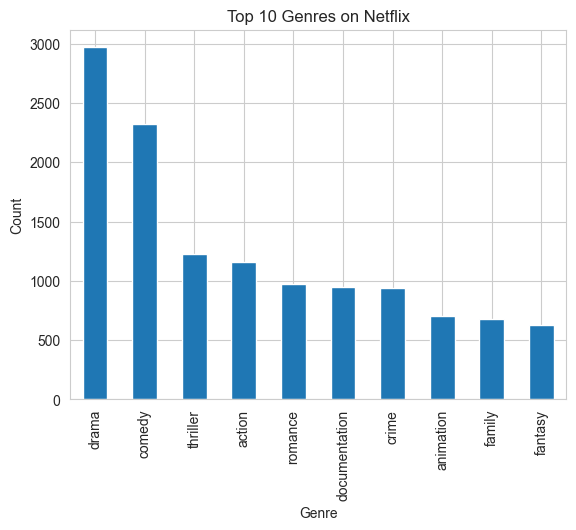

In [ ]:
df['genres'] = df['genres'].str.split(', ')
df_exploded = df.explode('genres')

top_genres = df_exploded['genres'].value_counts().head(10)

plt.figure()
top_genres.plot(kind='bar')
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

## 📈 Content Growth Over Time
### 🔍 Insight:
- Content production has increased significantly in recent years
- Streaming platforms have expanded rapidly
- Recent content dominates the dataset

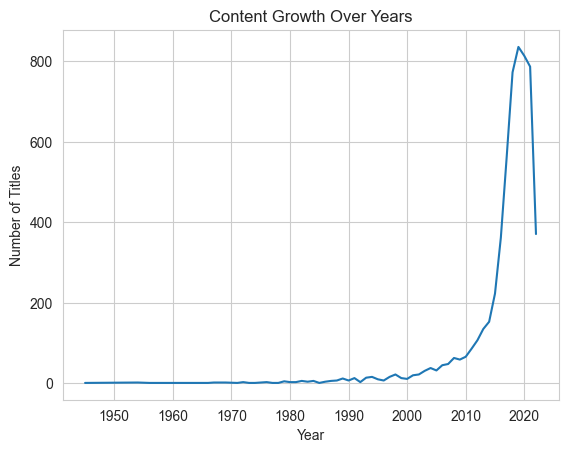

In [ ]:
content_trend = df['release_year'].value_counts().sort_index()

plt.figure()
content_trend.plot()
plt.title("Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

## 🎬 Movies vs TV Shows
### 🔍 Insight:
- Movies are more common than TV shows
- Indicates focus on short-form content

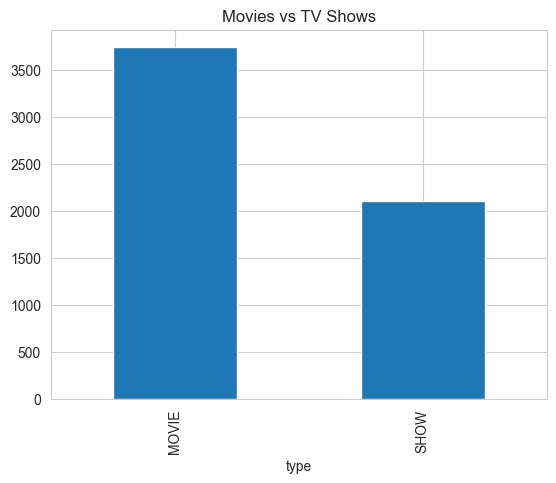

In [ ]:
type_counts = df['type'].value_counts()

plt.figure()
type_counts.plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.show()

## ⭐ IMDb Score Distribution
### 🔍 Insight:
- Most content falls between 6–8 rating
- Very high-rated content is rare
- Shows average quality of content

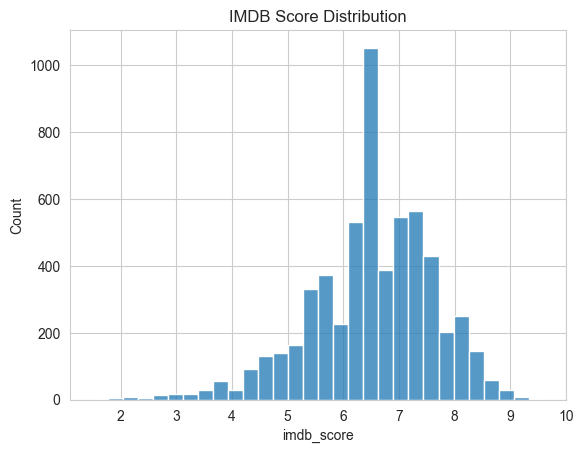

In [ ]:
plt.figure()
sns.histplot(df['imdb_score'], bins=30)
plt.title("IMDB Score Distribution")
plt.show()

## 🌍 Top Producing Countries
### 🔍 Insight:
- USA leads in content production
- India and UK also contribute significantly
- Shows global expansion of streaming platforms

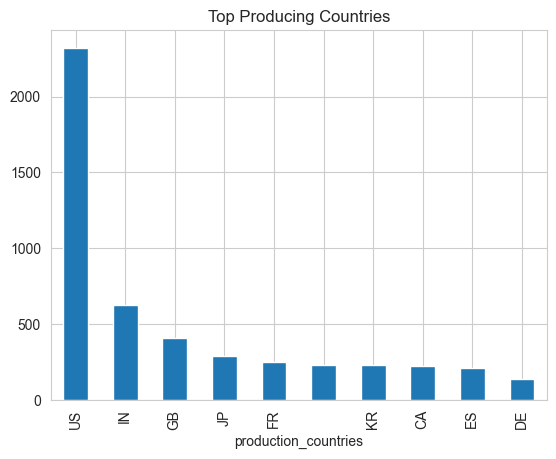

In [ ]:
df['production_countries'] = df['production_countries'].str.replace(r"[\[\]']", "", regex=True)
df['production_countries'] = df['production_countries'].str.split(', ')
df_country = df.explode('production_countries')

top_countries = df_country['production_countries'].value_counts().head(10)

plt.figure()
top_countries.plot(kind='bar')
plt.title("Top Producing Countries")
plt.show()

In [ ]:
top_rated = df[df['imdb_score'] > 8][['title', 'imdb_score']].sort_values(by='imdb_score', ascending=False)

top_rated.head(10)

,title,imdb_score
4425,#ABtalks,9.6
5029,Breaking Bad,9.5
3856,Khawatir,9.5
4875,Avatar: The Last Airbender,9.3
5633,Our Planet,9.3
4981,Reply 1988,9.2
3728,Major,9.1
5448,The Last Dance,9.1
5800,Kota Factory,9.1
5369,My Mister,9.1


In [ ]:
top_rated = df[df['tmdb_popularity'] > 8][['title', 'tmdb_popularity']].sort_values(by='tmdb_popularity', ascending=False)

top_rated.head(5)

,title,tmdb_popularity
416,Incantation,2274.044
5015,Stranger Things,2226.231
206,The Sea Beast,1723.363
3498,Valley of the Dead,1668.296
3185,The Man from Toronto,1439.906


In [ ]:
df['name'] = df['name'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))
df['genres'] = df['genres'].astype(str)
df['combined'] = (
    df['genres'] + " " + df['genres'] + " " +   # weighted
    df['description'] + " " +
    df['name']
)

## 🔤 Text Vectorization (TF-IDF)

We convert text (genres, description, cast) into numerical vectors.

- Important words get higher weight
- Common words get lower weight

This allows comparison between movies.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['combined'])

## 📐 Similarity Calculation

Cosine similarity measures how similar two movies are.

- 1 → very similar
- 0 → not similar

Used to recommend similar content.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(tfidf_matrix)

## 🤖 Recommendation System

We recommend movies based on:
- genres
- description
- cast similarity

The system finds movies with similar content.

In [ ]:
def recommend(title):
    if title not in df['title'].values:
        return "Title not found"

    idx = df[df['title'] == title].index[0]
    scores = list(enumerate(similarity[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    top = scores[1:11]
    return df.iloc[[i[0] for i in top]][['title', 'imdb_score']]

In [ ]:
# def recommend_by_id(movie_id):
#     idx = df[df['id'] == movie_id].index[0]
#     scores = list(enumerate(similarity[idx]))
#     scores = sorted(scores, key=lambda x: x[1], reverse=True)

#     top = scores[1:11]
#     return df.iloc[[i[0] for i in top]][['title', 'imdb_score']]

In [ ]:
recommend("Inception")

,title,imdb_score
1152,Dunkirk,7.800000
2015,The Dark Knight Rises,8.400000
2770,Argo,7.700000
663,Dragons: Dawn Of The Dragon Racers,6.464901
696,LEGO DC Comics Super Heroes: Batman Be-Leaguered,6.500000
5496,Beyblade Burst Turbo,6.464901
1496,iBoy,6.000000
2488,To All the Boys: P.S. I Still Love You,6.000000
3241,Stowaway,5.600000
20,The Witcher: Nightmare of the Wolf,7.200000


## 🧠 Conclusion

- Drama and Comedy dominate Netflix content
- Content production has increased over time
- Ratings mostly fall in mid-range
- Data supports building a recommendation system

The final model recommends movies based on content similarity.